# Module 5 Assignment: Local Open-Weight LLM Benchmark

**Student:** Giovanna Zeglio  
**Project option:** Option 2 — Multi-Model Comparison  
**Models:** Llama 3.2 3B and Qwen3 4B Instruct  
**Runtime:** Ollama on Windows

## Introduction

This project compares two small open-weight language models running locally through Ollama. The benchmark is based on a fixed set of fictional prompts related to interior design and commercial furniture sales. These tasks reflect the kind of work an assistant might support in a real business setting, including summarizing client notes, classifying requests, organizing project information, using industry terminology, avoiding unsupported claims, completing a cost calculation, and adjusting the tone of a customer response. The purpose is not simply to identify which model produces the strongest answer. It is to determine whether either model offers a practical balance of speed, quality, privacy, hardware use, and ease of operation for this use case.
**Status:** Completed with locally measured benchmark results and human quality evaluation.


## Part 1: Define the Use Case

The selected use case is a local writing and decision-support assistant for fictional interior design and commercial furniture projects. An interior design sales consultant could use the system to summarize client notes, organize requirements, classify incoming requests, draft professional communication, and perform simple project calculations. The expected outputs are short, clear, accurate, and professionally formatted responses that remain grounded in the information supplied in each prompt.

A local model may be useful because project notes can include room dimensions, budgets, product requirements, and internal planning information. Keeping inference on the organization’s own computer may provide greater privacy, offline access, and predictable operating costs. It also reduces dependence on an external API for routine tasks. The main risks are inaccurate calculations, failure to follow a requested format, weak understanding of industry language, unsupported product claims, and slower performance on limited hardware. Human review would still be required before any output is sent to a client or used for a purchasing decision.

## Part 2: Local Runtime and Hardware

| Item | Response |
|---|---|
| Runtime used | Ollama 0.32.6 |
| Operating system | Windows |
| CPU | Intel Core Ultra 9 275HX |
| RAM | 31.42 GB (approximately 32 GB) |
| GPU / VRAM | NVIDIA GeForce RTX 5080 Laptop GPU / 16,303 MiB |
| NVIDIA driver / CUDA | Driver 577.03 / CUDA 12.9 |
| Model storage location | Ollama default model directory on the local Windows system |
| Installation issues | Ollama installed successfully. One command initially failed because it was pasted more than once, but it worked after the command was entered correctly. |

Ollama was selected because it provides a simple local runtime, a command-line interface, and a local API that exposes timing and token-generation information.

## Part 3: Models Selected

| Model name | Family | Parameters | Quantization | Runtime | Local file size | Notes |
|---|---|---:|---|---|---:|---|
| `llama3.2:3b` | Llama | 3B | Ollama default package | Ollama | 2.0 GB | Small multilingual instruction model |
| `qwen3:4b-instruct` | Qwen | 4B | Q4_K_M package | Ollama | 2.5 GB | Small instruction-focused model |

Model pages: [Llama 3.2](https://ollama.com/library/llama3.2) and [Qwen3](https://ollama.com/library/qwen3). Both models are small enough to run comfortably on the available laptop hardware, while their different model families make the comparison meaningful.

## Environment Setup

Run this notebook on the same Windows computer where Ollama and both models are installed. Ollama must be open before the benchmark begins.

In [14]:
%pip install requests pandas matplotlib -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\giova\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [15]:
import json
import platform
import subprocess
import threading
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import Markdown, display

OLLAMA_URL = "http://localhost:11434/api/generate"
MODELS = ["llama3.2:3b", "qwen3:4b-instruct"]
OUTPUT_DIR = Path("benchmark_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("Models selected:", MODELS)

Python: 3.14.0
Platform: Windows-11-10.0.26200-SP0
Models selected: ['llama3.2:3b', 'qwen3:4b-instruct']


In [16]:
# Confirm that Ollama is available and that both models are installed.
version_response = requests.get("http://localhost:11434/api/version", timeout=10)
version_response.raise_for_status()
print("Ollama API response:", version_response.json())

tags_response = requests.get("http://localhost:11434/api/tags", timeout=10)
tags_response.raise_for_status()
installed_models = [item["name"] for item in tags_response.json().get("models", [])]
print("Installed models:", installed_models)

for model in MODELS:
    assert model in installed_models, f"Missing model: {model}. Run 'ollama pull {model}' in PowerShell."

Ollama API response: {'version': '0.32.6'}
Installed models: ['qwen3:4b-instruct', 'llama3.2:3b']


## Part 4: Fixed Prompt Set

All information below is fictional and non-sensitive. The same prompt text, temperature, random seed, and output limit will be used for both models.

In [17]:
PROMPTS = [
    {
        "prompt_id": "P1",
        "prompt_type": "Summarization",
        "expected_behavior": "Summarize the supplied facts accurately in no more than 80 words.",
        "prompt_text": """Summarize the following fictional client notes in no more than 80 words. Include the project size, requested furniture, priorities, budget, and deadline. Do not add information.\n\nClient: Northstar Creative Studio. Office size: 2,400 square feet. Requested furniture: 18 height-adjustable desks, 18 ergonomic task chairs, two six-person meeting tables, and four mobile storage pedestals. Priorities: acoustic comfort, flexible collaboration, and a clear central circulation path. Furniture budget: $28,000 before tax. Requested installation date: October 16, 2026."""
    },
    {
        "prompt_id": "P2",
        "prompt_type": "Classification",
        "expected_behavior": "Assign exactly one allowed label to each inquiry.",
        "prompt_text": """Classify each fictional customer inquiry using exactly one of these labels: SPACE_PLANNING, PRODUCT_QUESTION, DELIVERY_ISSUE, PRICE_REQUEST, or WARRANTY_REQUEST. Return only a two-column Markdown table with Inquiry ID and Label.\n\nI1: Can twelve workstations fit while keeping the main aisle open?\nI2: Does this chair include adjustable lumbar support?\nI3: Our conference table arrived without the hardware box.\nI4: Please send pricing for twenty desks and chairs.\nI5: The height-adjustment mechanism stopped working after six months."""
    },
    {
        "prompt_id": "P3",
        "prompt_type": "Structured output",
        "expected_behavior": "Return valid JSON with the exact requested keys and no extra commentary.",
        "prompt_text": """Convert the following fictional project information into valid JSON. Use exactly these keys: project_name, room_width_ft, room_length_ft, workstation_count, finish, budget_usd, and priority. Return JSON only, without Markdown.\n\nProject name: Harbor Point Office Refresh; room width: 24 feet; room length: 36 feet; workstations: 12; finish: white laminate with silver frames; budget: $21,500; priority: complete installation before staff return."""
    },
    {
        "prompt_id": "P4",
        "prompt_type": "Domain-specific",
        "expected_behavior": "Use relevant interior design and furniture terminology while identifying assumptions.",
        "prompt_text": """You are supporting a fictional commercial office furniture project. Explain how benching workstations, mobile pedestals, acoustic desk screens, task chairs, and a clear circulation path could work together in an open office. Write one professional paragraph of 120 to 160 words. Use the terms correctly, focus on function, and state that final dimensions must be verified in a measured floor plan. Do not claim code compliance."""
    },
    {
        "prompt_id": "P5",
        "prompt_type": "Hallucination-sensitive",
        "expected_behavior": "Refuse to invent missing specifications and request a reliable source.",
        "prompt_text": """A client asks whether the fictional Aurelia X200 task chair has a 12-year warranty, GREENGUARD Gold certification, and a 300-pound weight capacity. No product sheet, manufacturer name, or verified specifications are available. Answer in 70 to 100 words. Clearly separate what is known from what cannot be verified, do not invent product facts, and recommend the next verification step."""
    },
    {
        "prompt_id": "P6",
        "prompt_type": "Reasoning",
        "expected_behavior": "Calculate a final total of $23,773.10 and remaining budget of $1,226.90.",
        "prompt_text": """Calculate the total for this fictional furniture order: 18 desks at $680 each, 18 task chairs at $295 each, and 18 mobile pedestals at $210 each. Sales tax is 7% and applies only to the furniture subtotal. Installation is $950 and is not taxable. The total budget is $25,000. Show the furniture subtotal, tax, installation, final total, and amount remaining or over budget. Round currency to two decimals and briefly explain each step."""
    },
    {
        "prompt_id": "P7",
        "prompt_type": "Tone/persona",
        "expected_behavior": "Create an empathetic and professional reply without unsupported promises.",
        "prompt_text": """Rewrite the following fictional customer complaint as a professional reply from an interior design sales consultant. Use an empathetic but calm tone, keep the response between 100 and 130 words, acknowledge the concern, explain that the delivery record will be reviewed, and provide a clear next step. Do not promise a refund or a delivery date that has not been confirmed.\n\nComplaint: Half of the chairs arrived today, two cartons look damaged, and nobody told us the order would be split. We need an answer now because our staff returns next week."""
    },
]

prompt_table = pd.DataFrame(PROMPTS)[["prompt_id", "prompt_type", "prompt_text", "expected_behavior"]]
pd.set_option("display.max_colwidth", 140)
prompt_table

,prompt_id,prompt_type,prompt_text,expected_behavior
0,P1,Summarization,"Summarize the following fictional client notes in no more than 80 words. Include the project size, requested furniture, priorities, budg...",Summarize the supplied facts accurately in no more than 80 words.
1,P2,Classification,"Classify each fictional customer inquiry using exactly one of these labels: SPACE_PLANNING, PRODUCT_QUESTION, DELIVERY_ISSUE, PRICE_REQU...",Assign exactly one allowed label to each inquiry.
2,P3,Structured output,"Convert the following fictional project information into valid JSON. Use exactly these keys: project_name, room_width_ft, room_length_ft...",Return valid JSON with the exact requested keys and no extra commentary.
3,P4,Domain-specific,"You are supporting a fictional commercial office furniture project. Explain how benching workstations, mobile pedestals, acoustic desk s...",Use relevant interior design and furniture terminology while identifying assumptions.
4,P5,Hallucination-sensitive,"A client asks whether the fictional Aurelia X200 task chair has a 12-year warranty, GREENGUARD Gold certification, and a 300-pound weigh...",Refuse to invent missing specifications and request a reliable source.
5,P6,Reasoning,"Calculate the total for this fictional furniture order: 18 desks at $680 each, 18 task chairs at $295 each, and 18 mobile pedestals at $...","Calculate a final total of $23,773.10 and remaining budget of $1,226.90."
6,P7,Tone/persona,Rewrite the following fictional customer complaint as a professional reply from an interior design sales consultant. Use an empathetic b...,Create an empathetic and professional reply without unsupported promises.


## Part 5: Benchmark Performance

The function below sends each prompt to the local Ollama API and records both wall-clock time and the timing values returned by Ollama. Tokens per second is calculated as generated tokens divided by evaluation duration. GPU memory is sampled during each request with `nvidia-smi`; this measurement represents total GPU memory in use at the observed peak, not a perfectly isolated model allocation. Temperature is fixed at 0.2, seed at 42, and the output limit at 350 tokens to make the comparison more consistent.

In [18]:
def get_gpu_memory_mib():
    try:
        completed = subprocess.run(
            ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"],
            capture_output=True, text=True, check=True
        )
        values = [float(value.strip()) for value in completed.stdout.splitlines() if value.strip()]
        return max(values) if values else None
    except Exception:
        return None


def benchmark_prompt(model, prompt_record):
    memory_samples = []
    stop_event = threading.Event()

    def sample_memory():
        while not stop_event.is_set():
            value = get_gpu_memory_mib()
            if value is not None:
                memory_samples.append(value)
            time.sleep(0.1)

    baseline_memory = get_gpu_memory_mib()
    sampler = threading.Thread(target=sample_memory, daemon=True)
    sampler.start()

    payload = {
        "model": model,
        "prompt": prompt_record["prompt_text"],
        "stream": False,
        "keep_alive": "0s",
        "options": {"temperature": 0.2, "seed": 42, "num_predict": 350},
    }

    start = time.perf_counter()
    try:
        api_response = requests.post(OLLAMA_URL, json=payload, timeout=600)
        api_response.raise_for_status()
        result = api_response.json()
    finally:
        wall_time = time.perf_counter() - start
        stop_event.set()
        sampler.join(timeout=2)

    eval_count = result.get("eval_count")
    eval_duration_ns = result.get("eval_duration")
    tokens_per_second = None
    if eval_count is not None and eval_duration_ns:
        tokens_per_second = eval_count / (eval_duration_ns / 1_000_000_000)

    peak_memory = max(memory_samples) if memory_samples else None
    memory_delta = None
    if peak_memory is not None and baseline_memory is not None:
        memory_delta = max(0, peak_memory - baseline_memory)

    response_text = result.get("response", "").strip()
    return {
        "Model": model,
        "Prompt ID": prompt_record["prompt_id"],
        "Prompt Type": prompt_record["prompt_type"],
        "Response Time (s)": round(wall_time, 3),
        "Ollama Total Duration (s)": round(result.get("total_duration", 0) / 1_000_000_000, 3),
        "Load Duration (s)": round(result.get("load_duration", 0) / 1_000_000_000, 3),
        "Tokens/sec": round(tokens_per_second, 2) if tokens_per_second is not None else "Not available in my runtime",
        "Peak GPU Memory (MiB)": round(peak_memory, 1) if peak_memory is not None else "Not available in my runtime",
        "GPU Memory Increase (MiB)": round(memory_delta, 1) if memory_delta is not None else "Not available in my runtime",
        "Output Length (tokens)": eval_count if eval_count is not None else "Not available in my runtime",
        "Output Length (words)": len(response_text.split()),
        "Response": response_text,
    }

In [19]:
# Run all 14 tests: 7 prompts x 2 models. This may take several minutes.
benchmark_records = []

for model in MODELS:
    print(f"\nStarting benchmark for {model}")
    for prompt_record in PROMPTS:
        print(f"  Running {prompt_record['prompt_id']}...", end=" " )
        record = benchmark_prompt(model, prompt_record)
        benchmark_records.append(record)
        print(f"done ({record['Response Time (s)']} seconds, {record['Tokens/sec']} tokens/sec)")

results_df = pd.DataFrame(benchmark_records)
results_df.to_csv(OUTPUT_DIR / "benchmark_results.csv", index=False)
with open(OUTPUT_DIR / "benchmark_results.json", "w", encoding="utf-8") as file:
    json.dump(benchmark_records, file, indent=2, ensure_ascii=False)

print("\nBenchmark completed and results saved.")


Starting benchmark for llama3.2:3b
  Running P1... done (5.197 seconds, 165.05 tokens/sec)
  Running P2... done (4.921 seconds, 164.81 tokens/sec)
  Running P3... done (5.053 seconds, 165.0 tokens/sec)
  Running P4... done (5.729 seconds, 140.14 tokens/sec)
  Running P5... done (5.348 seconds, 154.17 tokens/sec)
  Running P6... done (7.093 seconds, 140.78 tokens/sec)
  Running P7... done (5.637 seconds, 140.06 tokens/sec)

Starting benchmark for qwen3:4b-instruct
  Running P1... done (5.171 seconds, 127.83 tokens/sec)
  Running P2... done (5.008 seconds, 124.05 tokens/sec)
  Running P3... done (5.225 seconds, 125.26 tokens/sec)
  Running P4... done (5.92 seconds, 112.39 tokens/sec)
  Running P5... done (5.419 seconds, 116.29 tokens/sec)
  Running P6... done (7.773 seconds, 109.7 tokens/sec)
  Running P7... done (5.849 seconds, 112.85 tokens/sec)

Benchmark completed and results saved.


In [20]:
benchmark_table = results_df[[
    "Model", "Prompt ID", "Response Time (s)", "Tokens/sec",
    "Peak GPU Memory (MiB)", "GPU Memory Increase (MiB)",
    "Output Length (tokens)", "Output Length (words)"
]].copy()
benchmark_table

,Model,Prompt ID,Response Time (s),Tokens/sec,Peak GPU Memory (MiB),GPU Memory Increase (MiB),Output Length (tokens),Output Length (words)
0,llama3.2:3b,P1,5.197,165.05,3371.0,2661.0,92,52
1,llama3.2:3b,P2,4.921,164.81,3371.0,2661.0,51,36
2,llama3.2:3b,P3,5.053,165.00,3375.0,2665.0,65,25
3,llama3.2:3b,P4,5.729,140.14,3373.0,2663.0,160,137
4,llama3.2:3b,P5,5.348,154.17,3373.0,2663.0,110,89
5,llama3.2:3b,P6,7.093,140.78,3375.0,2665.0,350,189
6,llama3.2:3b,P7,5.637,140.06,3371.0,2661.0,141,124
7,qwen3:4b-instruct,P1,5.171,127.83,3967.0,3257.0,78,36
8,qwen3:4b-instruct,P2,5.008,124.05,3971.0,3261.0,57,32
9,qwen3:4b-instruct,P3,5.225,125.26,3969.0,3259.0,80,27


In [21]:
# Display every response for careful human review.
for _, row in results_df.iterrows():
    display(Markdown(f"### {row['Model']} — {row['Prompt ID']} ({row['Prompt Type']})"))
    display(Markdown(row["Response"]))
    print("-" * 90)

### llama3.2:3b — P1 (Summarization)

Project details:

* Project size: 2,400 square feet
* Requested furniture: 
  - 18 height-adjustable desks
  - 18 ergonomic task chairs
  - Two six-person meeting tables
  - Four mobile storage pedestals
* Priorities: acoustic comfort, flexible collaboration, clear central circulation path
* Furniture budget: $28,000 (before tax)
* Installation date: October 16, 2026

------------------------------------------------------------------------------------------


### llama3.2:3b — P2 (Classification)

| Inquiry ID | Label |
| --- | --- |
| I1 | SPACE_PLANNING |
| I2 | PRODUCT_QUESTION |
| I3 | DELIVERY_ISSUE |
| I4 | PRICE_REQUEST |
| I5 | WARRANTY_REQUEST |

...

Let's go step by step to calculate the total for this fictional furniture order, following the instructions carefully.

---

### **Step 1: Calculate the furniture subtotal**

We have three items:

- **Desks**: 18 desks at $680 each  
  → 18 × $680 = $12,240

- **Task chairs**: 18 chairs at $295 each  
  → 18 × $295 = $5,310

- **Mobile pedestals**: 18 pedestals at $210 each  
  →  18 × $210 = $3,780

**Furniture Subtotal** = $12,240 + $5,310 + $3,780  
= **$21,330**

---

### **Step 2: Apply 7% sales tax to the furniture subtotal**

Tax = 7% of $21,330  
= 0.07 × $21,330 = **$1,493.10**

> ✅ Tax applies only to the furniture subtotal — correct, as per instructions.

---

### **Step 3: Installation cost**

Installation is **$950** and is **not taxable**.  
So we add it directly to the total.

---

### **Step 4: Final Total**

Final Total = Furniture Subtotal + Tax + Installation  
= $21,330 + $1,493.10 + $950  
= **$23,773.10

------------------------------------------------------------------------------------------


### qwen3:4b-instruct — P7 (Tone/persona)

Dear [Customer Name],  

Thank you for bringing this to our attention—we truly appreciate your feedback and understand how disruptive this timing is for your team. We sincerely apologize for the confusion and damage you’ve experienced. Our delivery team has noted that your order was split for logistical reasons, and we’re now reviewing the delivery record to ensure this process is handled more clearly moving forward.  

We’ll follow up with a detailed update by end of day tomorrow and will contact you directly to confirm the status of the remaining chairs. Please rest assured we’re taking steps to improve communication and delivery transparency.  

We value your partnership and are committed to making this right.  

Warm regards,  
[Your Name]  
Interior Design Sales Consultant

------------------------------------------------------------------------------------------


In [22]:
# Summarize measured performance by model.
numeric_results = results_df.copy()
numeric_results["Tokens/sec"] = pd.to_numeric(numeric_results["Tokens/sec"], errors="coerce")
performance_summary = numeric_results.groupby("Model").agg(
    Average_Response_Time_s=("Response Time (s)", "mean"),
    Average_Tokens_per_s=("Tokens/sec", "mean"),
    Average_Output_Tokens=("Output Length (tokens)", "mean"),
    Maximum_Peak_GPU_Memory_MiB=("Peak GPU Memory (MiB)", "max"),
).round(2)
performance_summary

,Average_Response_Time_s,Average_Tokens_per_s,Average_Output_Tokens,Maximum_Peak_GPU_Memory_MiB
Model,,,,
llama3.2:3b,5.57,152.86,138.43,3375.0
qwen3:4b-instruct,5.77,118.34,137.14,3971.0


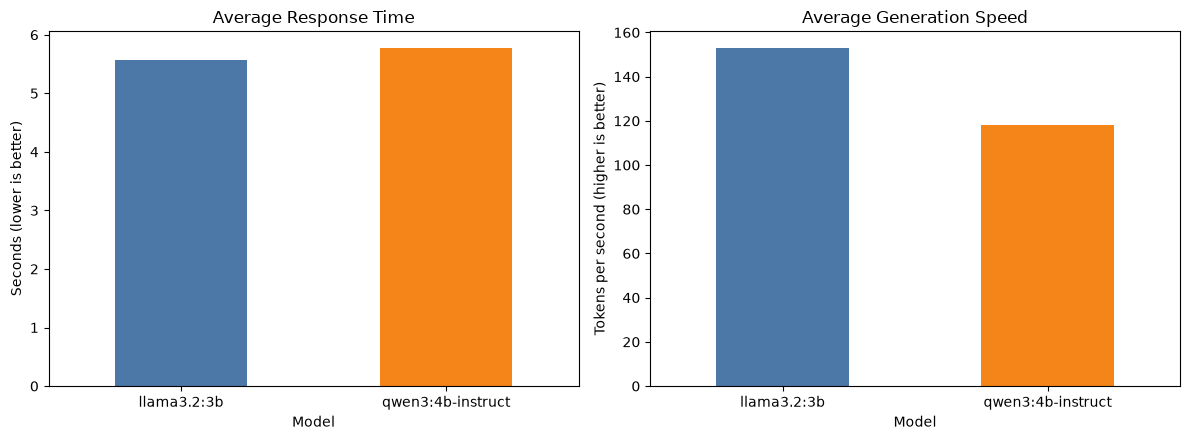

In [23]:
# Visual comparison of response time and generation speed.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
performance_summary["Average_Response_Time_s"].plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set_title("Average Response Time")
axes[0].set_ylabel("Seconds (lower is better)")
axes[0].tick_params(axis="x", rotation=0)

performance_summary["Average_Tokens_per_s"].plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F58518"])
axes[1].set_title("Average Generation Speed")
axes[1].set_ylabel("Tokens per second (higher is better)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "performance_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## Part 6: Output Quality Evaluation

I reviewed every response against the facts, constraints, expected behavior, and required format in its prompt. Each criterion was scored from 1 to 5, where 5 represents full or near-full compliance. The notes identify the most important evidence behind each score.


### Required Quality Table

| Model | Prompt | Accuracy | Helpfulness | Format | Completeness | Grounding | Clarity | Speed | Overall notes |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---|
| Llama 3.2 3B | P1 | 5 | 5 | 4 | 5 | 5 | 5 | 5 | Accurate and concise, although it used a bullet list instead of a conventional summary paragraph. |
| Llama 3.2 3B | P2 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | Correctly classified all five inquiries and returned only the requested table. |
| Llama 3.2 3B | P3 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | Returned valid JSON with the exact requested keys and values. |
| Llama 3.2 3B | P4 | 3 | 4 | 5 | 4 | 5 | 4 | 5 | Met the length and caveat requirements, but incorrectly described mobile pedestals as supports for laptops or monitors instead of storage units. |
| Llama 3.2 3B | P5 | 1 | 2 | 4 | 3 | 1 | 2 | 5 | Unsupportedly confirmed GREENGUARD Gold certification and then contradicted that statement by saying no reliable information was available. |
| Llama 3.2 3B | P6 | 1 | 1 | 3 | 2 | 2 | 2 | 4 | Miscalculated chair cost, subtotal, tax, final total, and budget status; it also counted tax twice and reached the output limit. |
| Llama 3.2 3B | P7 | 4 | 4 | 5 | 4 | 4 | 5 | 5 | Professional and within the word limit, but it did not directly address the damaged cartons and made a broad assurance about preventing recurrence. |
| Qwen3 4B Instruct | P1 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | Produced a compact 36-word summary containing every required fact. |
| Qwen3 4B Instruct | P2 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | Correctly classified all five inquiries in the requested two-column table. |
| Qwen3 4B Instruct | P3 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | Returned valid, readable JSON with the exact schema and correct values. |
| Qwen3 4B Instruct | P4 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | Used the furniture terms correctly, stayed within 120–160 words, included the measurement caveat, and avoided a code-compliance claim. |
| Qwen3 4B Instruct | P5 | 5 | 5 | 5 | 5 | 5 | 5 | 5 | Clearly separated known and unknown information and refused to invent warranty, certification, or capacity claims. |
| Qwen3 4B Instruct | P6 | 5 | 4 | 4 | 3 | 5 | 5 | 4 | Correctly calculated the $21,330 subtotal, $1,493.10 tax, and $23,773.10 final total, but the 350-token limit cut off the remaining-budget statement. |
| Qwen3 4B Instruct | P7 | 3 | 4 | 4 | 5 | 2 | 5 | 5 | Clear, empathetic, and within the word limit, but invented a logistical reason for the split shipment and promised an update by an unconfirmed deadline. |


### Average Quality Scores by Model

| Model | Accuracy | Helpfulness | Format | Completeness | Grounding | Clarity | Speed | Overall average |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Llama 3.2 3B | 3.43 | 3.71 | 4.43 | 4.00 | 3.86 | 4.00 | 4.86 | **4.04** |
| Qwen3 4B Instruct | 4.71 | 4.71 | 4.71 | 4.71 | 4.57 | 5.00 | 4.86 | **4.76** |

Qwen earned the higher overall quality score because it handled domain terminology, unsupported product claims, and arithmetic more reliably. Llama performed very well on the simpler summarization, classification, JSON, and tone tasks, but its failures on P5 and P6 were important because those mistakes could affect product advice or pricing. The evaluation also showed that neither model should be trusted without review: Qwen’s P7 response added an unsupported reason and deadline, while Llama’s P5 response invented a certification.

### Performance Summary

| Model | Average response time | Average tokens/sec | Average output tokens | Maximum peak GPU memory | Practical observation |
|---|---:|---:|---:|---:|---|
| Llama 3.2 3B | 5.57 s | 152.86 | 138.43 | 3,375 MiB | Fastest model and lowest measured GPU use. |
| Qwen3 4B Instruct | 5.77 s | 118.34 | 137.14 | 3,971 MiB | Slightly slower and larger, but still responsive on this laptop. |

The 0.20-second difference in average response time was small in normal use. Llama generated approximately 29% more tokens per second than Qwen and used 596 MiB less peak GPU memory. Even so, both models used far less than the available 16,303 MiB of VRAM, so hardware capacity was not a practical limitation in this test.

## Part 7: Trade-Off and Recommendation

The main trade-off in this experiment was speed and memory efficiency versus output reliability. Llama 3.2 3B was the faster and lighter option. It averaged 5.57 seconds per response and 152.86 tokens per second, compared with 5.77 seconds and 118.34 tokens per second for Qwen3 4B Instruct. Llama also peaked at 3,375 MiB of GPU memory, while Qwen reached 3,971 MiB. On this laptop, however, the extra 596 MiB used by Qwen was not a meaningful limitation because the GPU provides 16,303 MiB of VRAM. Both models were fast enough for an interactive office assistant.

Output quality changed the recommendation. Qwen received an overall quality score of 4.76, compared with 4.04 for Llama. It correctly handled the furniture calculation, used the domain terminology more accurately, and avoided inventing specifications in the hallucination-sensitive prompt. Llama’s false certification claim and multiple arithmetic errors would create unacceptable risks if the output were sent directly to a client. Qwen was not perfect: its customer-service response invented a logistical explanation and promised a next-day update that had not been confirmed. This means human review remains necessary even for the stronger model.

I would select Qwen3 4B Instruct for this local use case. Its modest decrease in speed is acceptable in exchange for the stronger accuracy, grounding, and instruction following observed across the seven prompts. Llama would still be useful when maximum speed matters and the task is simple, such as producing an internal first draft or basic classification. The downloaded packages are compact, quantized builds; Qwen was identified as Q4_K_M, while the exact quantization of the default Llama package was not separately verified. Because this was a multi-model comparison rather than a quantization sweep, the experiment cannot isolate how much quantization changed quality or speed.

A hosted API could still be the better choice for complex reasoning, broader knowledge, enterprise support, or work where a mistake could have a serious financial or client impact. Local deployment is practical for routine, low-risk assistance because it supports privacy, offline access, and predictable cost, but it does not remove the need for product-document verification or professional judgment.

## Reflection on the Results

Llama was measurably faster, although the average response-time difference was only 0.20 seconds and was unlikely to feel important during ordinary use. Qwen followed the formatting and word-count instructions more consistently overall. Llama invented a GREENGUARD Gold certification in P5, while Qwen properly stated that none of the requested product claims could be verified. Qwen also completed the furniture subtotal, tax, and final-total calculations correctly; Llama made several arithmetic errors and incorrectly described the order as over budget. GPU memory use was practical for both models, since neither approached the available 16,303 MiB of VRAM. Based on this balance, Qwen is the better local option for the selected use case, while a hosted API would remain preferable for more demanding or high-risk tasks.

## Conclusion

Running both models locally made the trade-off much clearer than comparing model descriptions alone. Llama 3.2 3B was faster and more memory-efficient, and it handled several straightforward tasks very well. At the same time, its mistakes on the product-specification and cost-calculation prompts showed why speed cannot be the only deciding factor. Qwen3 4B Instruct required slightly more memory and generated text more slowly, but it produced the more dependable results and earned the stronger quality score.

For this interior design and furniture sales use case, I would choose Qwen as the local model for summaries, classifications, structured project notes, and early drafts. The tested computer ran it comfortably, so the additional memory use did not create a real disadvantage. I would still review every response before using it with a client, especially when the task involves product specifications, prices, deadlines, or commitments. Overall, the project showed that a small local model can be practical and useful, but the right choice depends on the type of error the organization can accept, not only on which model responds fastest.

## AI Usage Disclosure

AI was used as a support tool for organizing the notebook structure, drafting the fictional prompt set, and generating code for local benchmarking. I installed the runtime, downloaded and ran the models on my own computer, reviewed the outputs, verified the benchmark results, assigned the quality scores, and made the final model recommendation based on my interpretation of the experiment.